# Pandas Summary: Key Findings and Insights

This notebook consolidates the main findings and visualizations from the four pandas analysis notebooks:

1. **01_data_prep_and_core_relationships.ipynb**: Data loading, merging, per-capita features, and core relationships
2. **02_income_groups_and_carbon_efficiency.ipynb**: Income group analysis, efficiency metrics, and outlier detection
3. **03_electricity_mix_and_energy_use.ipynb**: Energy composition and emission source analysis
4. **04_clustering_and_cluster_dynamics.ipynb**: Clustering analysis and cluster-specific insights

Links:
- [Pandas notebook overview](README.md)
- [Shared helpers](../functions.py)

In [49]:
%load_ext autoreload
%autoreload 2

# Keep path handling independent from the current working directory.
# This lets the notebook run from the repository root, from notebooks/pandas,
# or from Jupyter's file browser without manually editing relative paths.
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    """Walk upward until the project root is found."""
    for candidate in [start] + list(start.parents):
        has_data = (candidate / 'data' / 'co2_data.csv').exists()
        has_helpers = (candidate / 'notebooks' / 'functions.py').exists()
        if has_data and has_helpers:
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
DATA_DIR = REPO_ROOT / 'data'

# Make the shared helper module importable from every notebook location.
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# Core data-analysis libraries used throughout the summary notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from functions import safe_divide

# Use a consistent visual style so figures look coherent in the final submission.
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Preparation and Core Relationships

### Key Findings:
- Data loaded and merged from CO2 and GDP sources
- Per-capita features engineered for analysis
- Core relationships between GDP and CO2 emissions established

In [50]:
# Load the local Our World in Data CO2 panel.
# Only country-level observations with valid ISO codes are kept; this removes
# aggregate rows such as continents or income groups that would distort country comparisons.
co2_df = pd.read_csv(DATA_DIR / 'co2_data.csv')
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']
co2_df = co2_df[selected_columns].copy()
co2_df = co2_df[co2_df['iso_code'].notna() & (co2_df['iso_code'].str.strip() != '')]
co2_df = co2_df[co2_df['year'] > 1960]

# Load World Bank GDP data and reshape it from wide format (one column per year)
# into a country-year panel that can be merged with the CO2 panel.
gdp_df = pd.read_csv(DATA_DIR / 'gdp_data.csv')
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)
gdp_df['year'] = gdp_df['year'].astype(int)
gdp_df['gdp'] = pd.to_numeric(gdp_df['gdp'], errors='coerce')
gdp_df = gdp_df.rename(columns={'Country Code': 'iso_code'})
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]
gdp_df = gdp_df.dropna(subset=['gdp'])

# Merge on ISO code and year so each row represents one country in one year.
base_df = co2_df.merge(gdp_df, on=['iso_code', 'year'], how='left')

# Normalize by population to make countries of different sizes comparable.
# OWID reports CO2 in million tonnes, so multiplying by 1e6 converts it to tonnes
# before calculating tonnes of CO2 per person.
base_df['co2_per_capita'] = safe_divide(base_df['co2'].values * 1e6, base_df['population'].values)
base_df['gdp_per_capita'] = safe_divide(base_df['gdp'].values, base_df['population'].values)

print(f'Loaded {len(base_df)} records covering {base_df["year"].min()}-{base_df["year"].max()}')
print(f'Countries: {base_df["country"].nunique()}')
print(f'Countries with GDP data: {base_df[base_df["gdp"].notna()]["country"].nunique()}')


Loaded 13952 records covering 1961-2024
Countries: 218
Countries with GDP data: 204


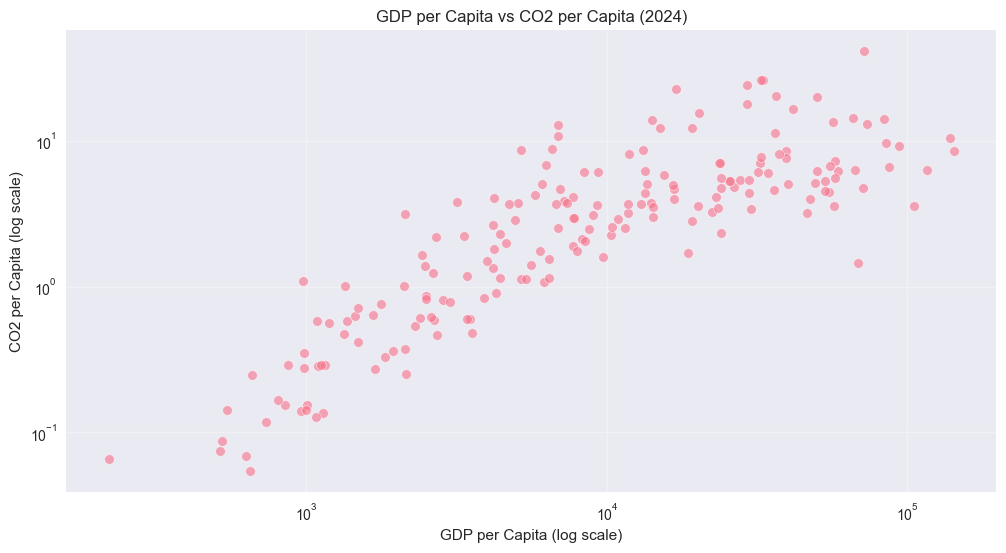

In [51]:
# Use the most recent year available in the merged panel for the main snapshot.
latest_year = base_df['year'].max()
latest_data = base_df[base_df['year'] == latest_year].copy()

# A log-log scatter plot is useful here because GDP and CO2 per capita vary by
# orders of magnitude across countries. The plot shows the broad relationship
# without letting a few very large values dominate the axes.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=latest_data, x='gdp_per_capita', y='co2_per_capita', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title(f'GDP per Capita vs CO2 per Capita ({latest_year})')
plt.xlabel('GDP per Capita (log scale)')
plt.ylabel('CO2 per Capita (log scale)')
plt.grid(True, alpha=0.3)
plt.show()


## 2. Income Groups and Carbon Efficiency

### Key Findings:
- Countries categorized into income groups based on GDP per capita
- Carbon intensity analysis reveals efficiency patterns
- Significant variation in emissions within income groups

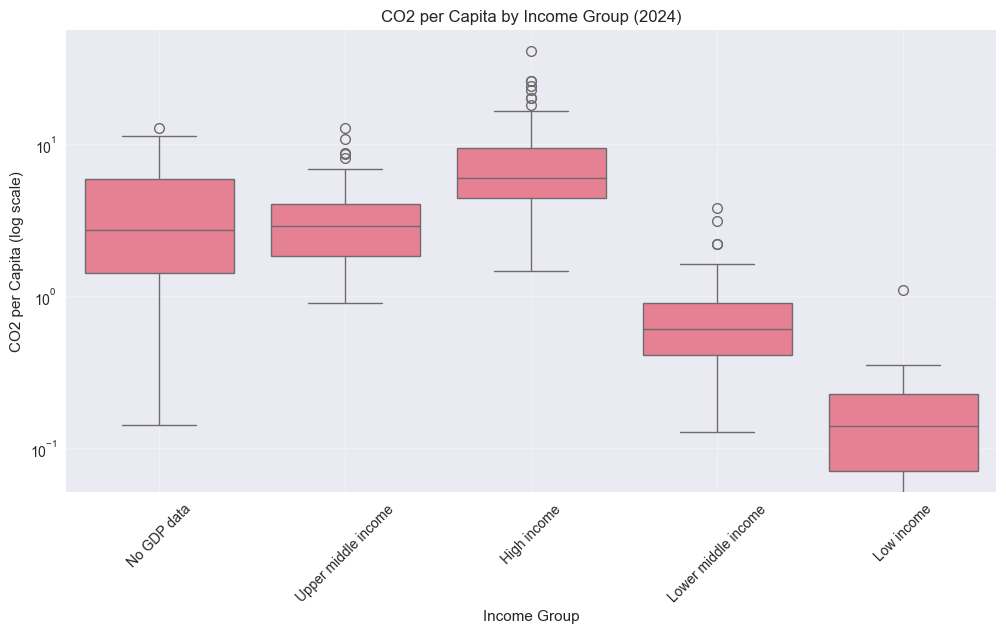

In [52]:
# Assign simple income groups from GDP per capita.
# These thresholds are used as practical comparison bands for this project;
# they are not meant to replace official historical World Bank classifications.
def assign_income_group(gdp_per_capita):
    if pd.isna(gdp_per_capita):
        return 'No GDP data'
    elif gdp_per_capita < 1000:
        return 'Low income'
    elif gdp_per_capita < 4000:
        return 'Lower middle income'
    elif gdp_per_capita < 12000:
        return 'Upper middle income'
    else:
        return 'High income'

latest_data['income_group'] = latest_data['gdp_per_capita'].apply(assign_income_group)

# Compare the distribution of per-capita emissions across income groups.
# The log scale keeps both low-emission and high-emission countries visible.
plt.figure(figsize=(12, 6))
sns.boxplot(data=latest_data, x='income_group', y='co2_per_capita')
plt.yscale('log')
plt.title(f'CO2 per Capita by Income Group ({latest_year})')
plt.xlabel('Income Group')
plt.ylabel('CO2 per Capita (log scale)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


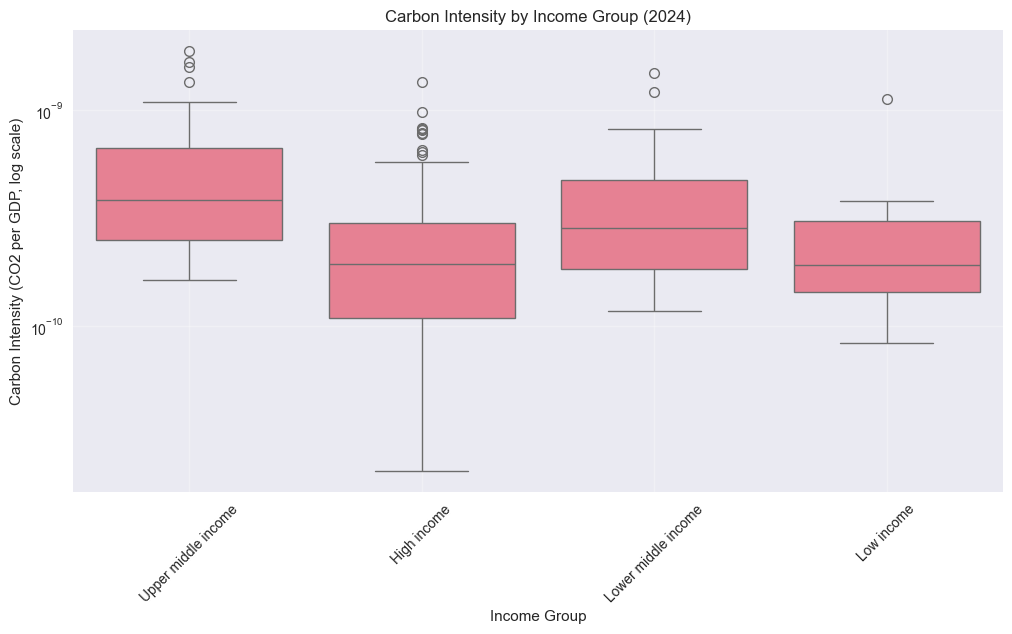

In [53]:
# Carbon intensity measures how much CO2 is produced per unit of GDP.
# Lower values indicate that an economy produces less CO2 for each dollar of output.
latest_data['carbon_intensity'] = latest_data['co2'] / latest_data['gdp']

# Remove rows without a valid carbon-intensity value before plotting.
carbon_data = latest_data.dropna(subset=['carbon_intensity', 'income_group'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=carbon_data, x='income_group', y='carbon_intensity')
plt.yscale('log')
plt.title(f'Carbon Intensity by Income Group ({latest_year})')
plt.xlabel('Income Group')
plt.ylabel('Carbon Intensity (CO2 per GDP, log scale)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


## 3. Energy Composition and Emission Sources

### Key Findings:
- Analysis of different CO2 sources from the comprehensive dataset
- Energy intensity patterns across countries
- Identification of countries with different emission profiles

In [54]:
# Reload the full CO2 file to access source and energy columns that were not
# needed in the compact base dataset above.
full_co2_df = pd.read_csv(DATA_DIR / 'co2_data.csv')
full_co2_df = full_co2_df[full_co2_df['iso_code'].notna() & (full_co2_df['iso_code'].str.strip() != '')]
full_co2_df = full_co2_df[full_co2_df['year'] > 1960]

# Add GDP and GDP-per-capita values from the already-cleaned base panel.
# This keeps the energy section consistent with the earlier country-year merge.
energy_df = full_co2_df.merge(
    base_df[['iso_code', 'year', 'gdp', 'gdp_per_capita']],
    on=['iso_code', 'year'],
    how='left'
)

# Focus the source/energy comparison on the latest available year.
latest_energy = energy_df[energy_df['year'] == latest_year].copy()
latest_energy['income_group'] = latest_energy['gdp_per_capita'].apply(assign_income_group)

available_energy_columns = [
    col for col in latest_energy.columns
    if any(keyword in col for keyword in ['coal', 'oil', 'gas', 'energy', 'cement', 'flaring'])
]

print(f'Energy data loaded: {len(latest_energy)} records for {latest_year}')
print(f'Available source/energy columns: {available_energy_columns}')


Energy data loaded: 218 records for 2024
Available columns: ['cement_co2', 'cement_co2_per_capita', 'co2_including_luc_per_unit_energy', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'cumulative_cement_co2', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_oil_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'oil_co2', 'oil_co2_per_capita', 'primary_energy_consumption', 'share_global_cement_co2', 'share_global_coal_co2', 'share_global_cumulative_cement_co2', 'share_global_cumulative_coal_co2', 'share_global_cumulative_flaring_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_oil_co2', 'share_global_flaring_co2', 'share_global_gas_co2', 'share_global_oil_co2']


<Figure size 1400x800 with 0 Axes>

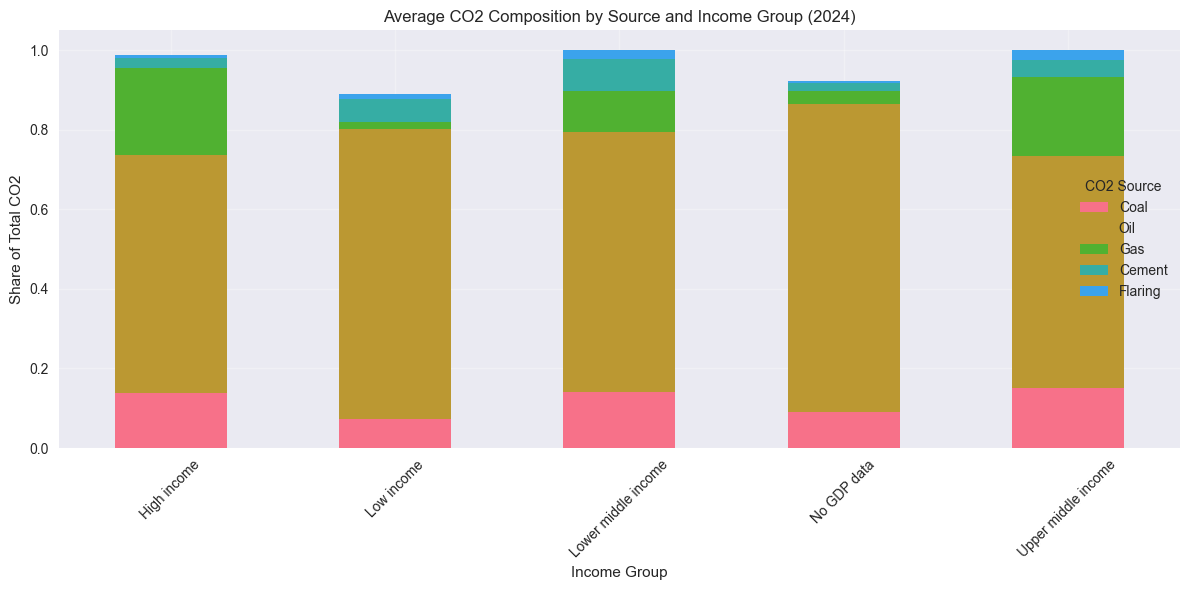

In [55]:
# Analyze the composition of CO2 emissions by source.
# These columns represent fossil-fuel and industrial components of total CO2.
source_columns = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2']
available_sources = [col for col in source_columns if col in latest_energy.columns]

if available_sources:
    # Sum the available source columns row-wise. Rows with zero source totals are
    # treated as missing for share calculations to avoid division-by-zero artifacts.
    latest_energy['total_sources'] = latest_energy[available_sources].sum(axis=1)
    latest_energy.loc[latest_energy['total_sources'] <= 0, 'total_sources'] = np.nan

    # Convert absolute source emissions into shares of each country's source total.
    for source in available_sources:
        latest_energy[f'{source}_share'] = latest_energy[source] / latest_energy['total_sources']

    # Average country-level source shares within each income group for comparison.
    source_share_columns = [f'{source}_share' for source in available_sources]
    source_shares = latest_energy[source_share_columns].fillna(0)
    source_shares_by_group = source_shares.groupby(latest_energy['income_group']).mean()

    ax = source_shares_by_group.plot(kind='bar', stacked=True, figsize=(12, 6))
    ax.set_title(f'Average CO2 Composition by Source and Income Group ({latest_year})')
    ax.set_xlabel('Income Group')
    ax.set_ylabel('Share of Total Source CO2')
    ax.legend(title='CO2 Source', labels=[source.replace('_co2', '').title() for source in available_sources])
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No CO2 source columns found in the dataset')


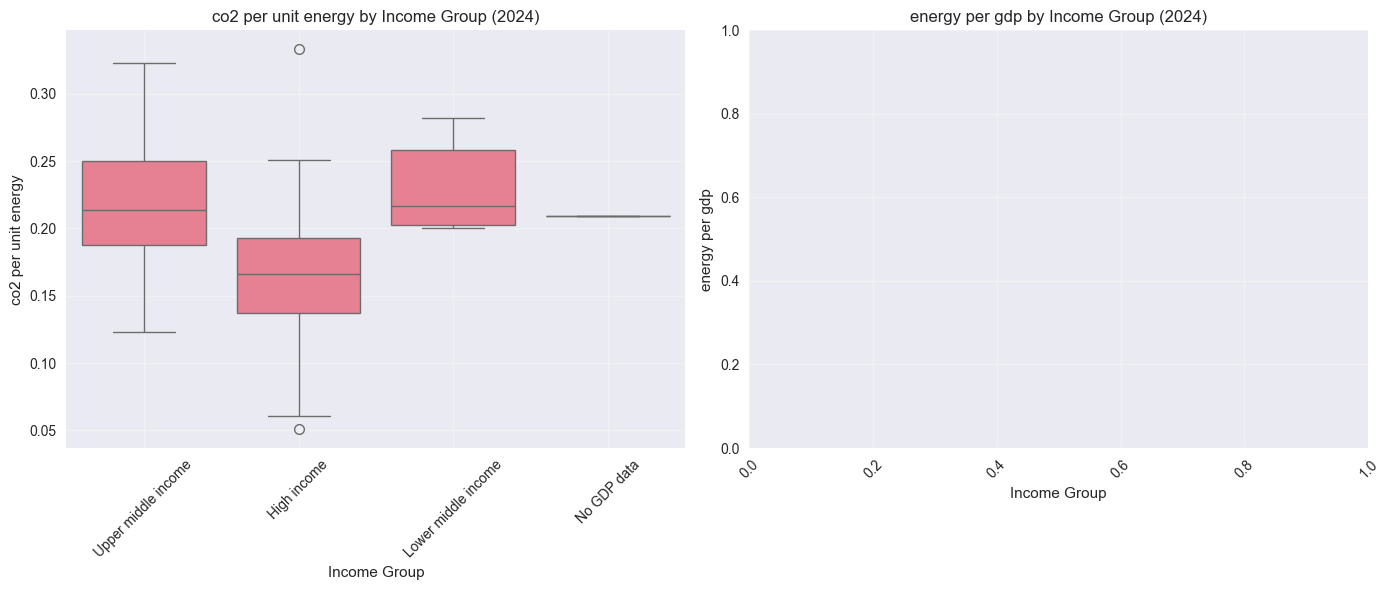

In [56]:
# Analyze energy-efficiency metrics when the latest-year data is actually available.
# Some columns can exist in the dataset but contain only missing values for 2024;
# checking non-null values prevents empty subplot panels.
efficiency_cols = ['co2_per_unit_energy', 'energy_per_gdp']
available_efficiency = [col for col in efficiency_cols if col in latest_energy.columns]

# Keep only metrics with at least one valid observation and report any skipped metrics.
valid_efficiency = []
for col in available_efficiency:
    valid_rows = latest_energy.dropna(subset=[col, 'income_group'])
    valid_rows = valid_rows[valid_rows['income_group'] != 'No GDP data']
    print(f'{col}: {len(valid_rows)} valid rows for {latest_year}')

    if not valid_rows.empty:
        valid_efficiency.append((col, valid_rows))
    else:
        print(f'  Skipping {col} because it has no usable latest-year values.')

if valid_efficiency:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(valid_efficiency),
        figsize=(7 * len(valid_efficiency), 6),
        squeeze=False
    )

    # Plot one boxplot per valid metric. Using explicit axes avoids subplot-index
    # mistakes and works correctly whether there is one metric or several.
    for ax, (col, efficiency_data) in zip(axes.ravel(), valid_efficiency):
        sns.boxplot(data=efficiency_data, x='income_group', y=col, ax=ax)
        ax.set_title(f'{col.replace("_", " ").title()} by Income Group ({latest_year})')
        ax.set_xlabel('Income Group')
        ax.set_ylabel(col.replace('_', ' ').title())
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
elif available_efficiency:
    print('Energy efficiency columns exist, but none contain usable values for the selected latest year.')
else:
    print('No energy efficiency columns found in the dataset')


## 4. Clustering and Cluster Dynamics

### Key Findings:
- K-means clustering identifies distinct country groups based on emission patterns
- Cluster analysis reveals different development and emission trajectories
- Visualization of clusters in GDP-CO2 space

In [57]:
# Prepare the latest-year variables used for clustering.
# KMeans cannot handle missing values, so rows are dropped after selecting the
# variables that define the country profiles.
cluster_data = latest_data[['gdp_per_capita', 'co2_per_capita']].copy()
cluster_data = cluster_data.dropna()

# Add carbon intensity as a third feature so clusters reflect both scale
# (GDP/emissions per person) and efficiency (emissions per GDP).
cluster_data['carbon_intensity'] = latest_data.loc[cluster_data.index, 'co2'] / latest_data.loc[cluster_data.index, 'gdp']
cluster_data = cluster_data.dropna()

# Standardize features before KMeans because the variables have different units
# and magnitudes. Without scaling, GDP per capita would dominate the distance metric.
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Fit a small KMeans model to identify broad country archetypes.
# The fixed random_state makes the clustering reproducible across runs.
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans.fit_predict(cluster_data_scaled)

# Store cluster labels back on the latest-year dataframe for plotting and summaries.
latest_data.loc[cluster_data.index, 'cluster'] = cluster_data['cluster']

print(f'Identified {n_clusters} clusters')
print('Cluster sizes:')
print(cluster_data['cluster'].value_counts().sort_index())


Identified 4 clusters
Cluster sizes:
cluster
0     23
1     35
2     10
3    121
Name: count, dtype: int64


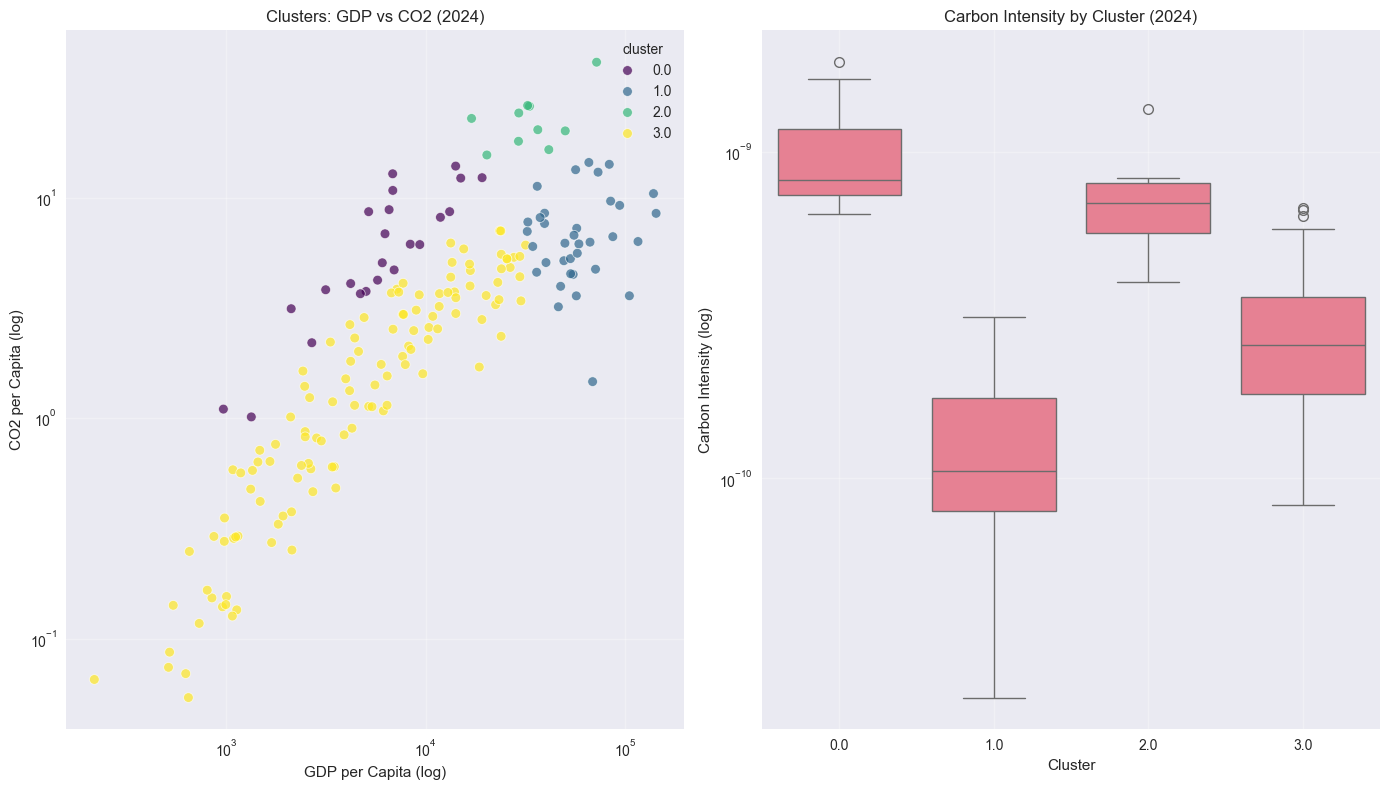

In [58]:
# Visualize the cluster assignments from two angles:
# 1. where countries sit in the GDP/emissions space;
# 2. how carbon intensity differs across the resulting groups.
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
cluster_plot_data = latest_data.dropna(subset=['cluster', 'gdp_per_capita', 'co2_per_capita'])
sns.scatterplot(
    data=cluster_plot_data,
    x='gdp_per_capita',
    y='co2_per_capita',
    hue='cluster',
    palette='viridis',
    alpha=0.7
)
plt.xscale('log')
plt.yscale('log')
plt.title(f'Clusters: GDP vs CO2 ({latest_year})')
plt.xlabel('GDP per Capita (log)')
plt.ylabel('CO2 per Capita (log)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cluster_carbon_data = latest_data.dropna(subset=['cluster', 'carbon_intensity'])
sns.boxplot(data=cluster_carbon_data, x='cluster', y='carbon_intensity')
plt.yscale('log')
plt.title(f'Carbon Intensity by Cluster ({latest_year})')
plt.xlabel('Cluster')
plt.ylabel('Carbon Intensity (log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [59]:
# Summarize the cluster profiles numerically.
# Means show the average profile, medians reduce the influence of extreme countries,
# and the country count shows how large each cluster is.
cluster_summary = latest_data.dropna(subset=['cluster', 'carbon_intensity']).groupby('cluster').agg({
    'gdp_per_capita': ['mean', 'median'],
    'co2_per_capita': ['mean', 'median'],
    'carbon_intensity': ['mean', 'median'],
    'country': 'count'
})

display(cluster_summary)

# Print a few country names from each cluster to make the abstract cluster labels
# easier to interpret in the written discussion.
print('\nExample countries from each cluster:')
for cluster in range(n_clusters):
    countries = latest_data[latest_data['cluster'] == cluster]['country'].head(5).tolist()
    print(f'Cluster {cluster}: {countries}')


gdp_per_capita               co2_per_capita             \
                  mean        median           mean     median   
cluster                                                          
0.0        7216.336997   6267.186814       6.633200   6.139200   
1.0       63442.911149  56454.446371       7.160596   6.338896   
2.0       36137.305601  32811.656111      23.154691  21.655469   
3.0        8224.343910   4421.165030       2.054449   1.509604   

        carbon_intensity               country  
                    mean        median   count  
cluster                                         
0.0         9.948842e-10  8.190701e-10      23  
1.0         1.283566e-10  1.054020e-10      35  
2.0         7.094334e-10  6.949967e-10      10  
3.0         2.844933e-10  2.554062e-10     121


Example countries from each cluster:
Cluster 0: ['Algeria', 'Belarus', 'Bosnia and Herzegovina', 'China', 'Curacao']
Cluster 1: ['Andorra', 'Aruba', 'Australia', 'Austria', 'Bahamas']
Cluster 2: ['Bahrain', 'Brunei', 'Kuwait', 'New Caledonia', 'Oman']
Cluster 3: ['Albania', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia']


## Summary and Key Insights

### Main Findings:

1. **GDP-CO2 Relationship**: There's a strong positive correlation between GDP per capita and CO2 emissions, though with significant variation across countries at similar income levels.

2. **Income Group Patterns**: High-income countries generally have higher CO2 emissions per capita, but also show more variation in carbon intensity, suggesting some have decoupled economic growth from emissions.

3. **Carbon Efficiency**: Significant differences in carbon intensity exist even within income groups, indicating that economic development doesn't necessarily require high emissions.

4. **Energy Composition**: Different income groups show distinct CO2 source profiles based on available data, with variations in coal, oil, gas, and other sources.

5. **Cluster Analysis**: The clustering reveals distinct groups:
   - High-income, high-emission countries
   - High-income, low-emission countries (efficient)
   - Middle-income, moderate-emission countries
   - Low-income, low-emission countries

### Policy Implications:

- The existence of high-income, low-emission countries suggests that economic prosperity can be decoupled from high carbon emissions
- Middle-income countries have opportunities to "leapfrog" to cleaner development paths
- Energy composition analysis shows that reducing dependence on high-carbon sources is a key leverage point
- Targeted policies could help different clusters based on their specific characteristics and challenges
- Countries with similar income levels but different emission profiles could learn from each other's strategies